In [1]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [5]:
tabla, jd, X = pc.consulta_horizons(
    id = "Apophis",
    epochs="2026-04-20",
    location="@SSB"
)
print(X)

[-4.54615645e+10  1.46498906e+11 -8.91205586e+09 -2.72244445e+04
 -4.00763765e+03 -4.30333986e+02]


In [14]:
rvec = X[:3]
r = np.linalg.norm(rvec)
vvec = X[3:]
v = np.linalg.norm(vvec)
rvec, vvec, 

(array([-4.54615645e+10,  1.46498906e+11, -8.91205586e+09]),
 array([-27224.44453608,  -4007.63764628,   -430.33398559]))

In [15]:
hvec = np.cross(rvec, vvec)
h = np.linalg.norm(hvec)

mu = pc.constantes.mu_sun
evec = np.cross(vvec, hvec) / mu - rvec / r
e = np.linalg.norm(evec)

nvec = np.cross([0, 0, 1], hvec)
n = np.linalg.norm(nvec)
hvec, h, evec, e, nvec, mu

(array([-9.87597487e+13,  2.23062114e+14,  4.17054482e+15]),
 np.float64(4177673308299585.5),
 array([ 0.17066034, -0.0976029 ,  0.00926159]),
 np.float64(0.19681731768435504),
 array([-2.23062114e+14, -9.87597487e+13,  0.00000000e+00]),
 1.3271244004127942e+20)

In [8]:
p = h**2 / mu
e = e
I = np.arccos(hvec[2] / h)
rad = 180 / np.pi
I*rad


np.float64(3.3475799477925516)

In [9]:
omegap = np.arccos(nvec@evec / (n * e))
omegap*rad

np.float64(126.30633780951213)

In [13]:
Omegap = np.arccos(nvec @ [1, 0, 0] / n)
#if nvec[1] > 0:
 #   Omegap = Omegap
#else:
 #       Omegap = 2 * np.pi - Omegap
Omega = Omegap if nvec[1] > 0 else 2 * np.pi - Omegap
Omega*rad

np.float64(203.8811521637987)

In [17]:
fp = np.arccos(evec @ rvec / (e * r))
f = fp if rvec @ vvec/r > 0 else 2 * np.pi - fp
f*rad

np.float64(137.0639111789069)

In [18]:
def rv_to_coe(rvec, vvec, mu):
    # Magnitudes de los vectores
    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)
    
    # Vector momento angular y su magnitud
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)
    
    # Vector excentricidad y su magnitud
    evec = np.cross(vvec, hvec) / mu - rvec / r
    e = np.linalg.norm(evec)
    
    # Vector nodo ascendente y su magnitud
    nvec = np.cross([0, 0, 1], hvec)
    n = np.linalg.norm(nvec)
    
    # Semilatus rectum (parámetro)
    p = h**2 / mu
    
    # Inclinación
    I = np.arccos(hvec[2] / h)
    
    # Longitud del nodo ascendente (Omega)
    if n != 0:
        Omega = np.arccos(nvec[0] / n)
        if nvec[1] < 0:
            Omega = 2 * np.pi - Omega
    else:
        Omega = 0
        
    # Argumento del periastro (omega)
    if n != 0 and e != 0:
        omega = np.arccos(np.dot(nvec, evec) / (n * e))
        if evec[2] < 0:
            omega = 2 * np.pi - omega
    else:
        omega = 0
        
    # Anomalía verdadera (f)
    if e != 0:
        f = np.arccos(np.dot(evec, rvec) / (e * r))
        if np.dot(rvec, vvec) < 0:
            f = 2 * np.pi - f
    else:
        f = 0
        
    return p, e, I, Omega, omega, f

In [20]:
p, e, I, Omega, omega, f = rv_to_coe(rvec, vvec, mu)
p, e, I*rad, Omega*rad, omega*rad, f*rad

(np.float64(131509557547.50772),
 np.float64(0.19681731768435504),
 np.float64(3.3475799477925516),
 np.float64(203.8811521637987),
 np.float64(126.30633780951213),
 np.float64(137.0639111789069))

In [33]:
#orbita del sol
tabla, jds, Xs = pc.consulta_horizons(
    id = "Sun",
    epochs=dict(start="2026-04-20", stop = "2038-04-20", step = "180d"),
    location="@SSB"
)
Xs = np.array(Xs)


C:\Users\nando\AppData\Local\Temp\ipykernel_18168\3227945894.py:42: RuntimeWarning: invalid value encountered in arccos
  f = np.arccos(np.dot(evec, rvec) / (e * r))


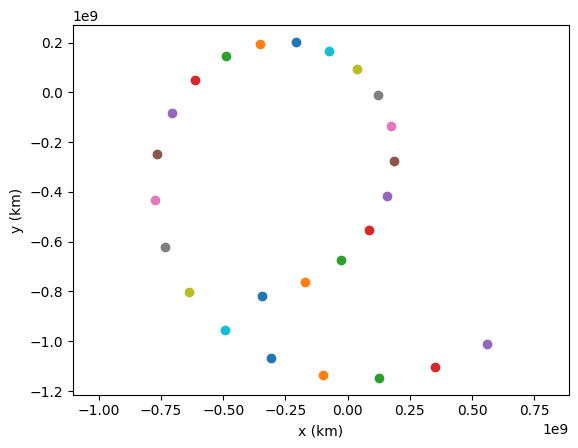

In [34]:
mu = pc.constantes.mu_sun + pc.constantes.mu_jupiter + pc.constantes.mu_saturn
for i, jd in  enumerate(jds):
    rvec = Xs[i, :3]
    vvec = Xs[i, 3:]
    p, e, I, Omega, omega, f = rv_to_coe(rvec, vvec, mu)
    
    plt.plot(rvec[0], rvec[1], 'o')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.axis('equal')
plt.show()

In [ ]:
# grafica e los elementos orbitales del sol
Es =